  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
Using cached jupyter-1.1.1-py2.py3-none-any.whl (2.7 kB)
Using cached jupyter_console-6.6.3-py3-none-any.whl (24 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

order_items = pd.read_csv('dataset/olist_order_items_dataset.csv')
order_reviews = pd.read_csv('dataset/olist_order_reviews_dataset.csv')

print("Order Items:")
print(order_items.head())
print("\nOrder Reviews:")
print(order_reviews.head())

Order Items:
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99 

In [3]:

df = order_items[['order_id', 'product_id', 'price']].merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)


df.to_csv('dataset/abo_sales_clean.csv', index=False)

print(df.head())

OSError: Cannot save file into a non-existent directory: 'C:\Myjupyterll'

In [4]:

product_analysis = df.groupby('product_id').agg(
    sales_count=('order_id', 'count'),  
    avg_price=('price', 'mean'),        
    avg_review_score=('review_score', 'mean')  
).reset_index()


print(product_analysis.head())

                         product_id  sales_count  avg_price  avg_review_score
0  00066f42aeeb9f3007548bb9d3f33c38            1     101.65               5.0
1  00088930e925c41fd95ebfe695fd2655            1     129.90               4.0
2  0009406fd7479715e4bef61dd91f2462            1     229.00               1.0
3  000b8f95fcb9e0096488278317764d19            2      58.90               5.0
4  000d9be29b5207b54e86aa1b1ac54872            1     199.00               5.0


In [6]:
import pandas as pd


order_items = pd.read_csv('C:/Myjupyterll/olist_order_items_dataset.csv')


print("Columns in order_items:", order_items.columns.tolist())

Columns in order_items: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [7]:

orders = pd.read_csv('C:/Myjupyterll/olist_orders_dataset.csv')


print("Columns in orders:", orders.columns.tolist())


print(orders.head())

Columns in orders: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 

In [8]:
import pandas as pd


order_items = pd.read_csv('C:/Myjupyterll/olist_order_items_dataset.csv')
order_reviews = pd.read_csv('C:/Myjupyterll/olist_order_reviews_dataset.csv')
orders = pd.read_csv('C:/Myjupyterll/olist_orders_dataset.csv')


merged_data = order_items.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')


df = merged_data[['order_id', 'product_id', 'price', 'order_purchase_timestamp']].merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)


df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')


df.to_csv('C:/Myjupyterll/abo_sales_with_time.csv', index=False)


print(df.head())

                           order_id                        product_id   price  \
0  00010242fe8c5a6d1ba2dd792cb16214  4244733e06e7ecb4970a6e2683c13e61   58.90   
1  00018f77f2f0320c557190d7a144bdd3  e5f2d52b802189ee658865ca93d83a8f  239.90   
2  000229ec398224ef6ca0657da4fc703e  c777355d18b72b67abbeef9df44fd0fd  199.00   
3  00024acbcdf0a6daa1e931b038114c75  7634da152a4610f1595efa32f14722fc   12.99   
4  00042b26cf59d7ce69dfabb4e55b4fd9  ac6c3623068f30de03045865e4e10089  199.90   

  order_purchase_timestamp  review_score year_month  
0      2017-09-13 08:59:02           5.0    2017-09  
1      2017-04-26 10:53:06           4.0    2017-04  
2      2018-01-14 14:33:31           5.0    2018-01  
3      2018-08-08 10:00:35           4.0    2018-08  
4      2017-02-04 13:57:51           5.0    2017-02  


In [9]:

product_analysis = df.groupby('product_id').agg(
    sales_count=('order_id', 'count'),
    avg_price=('price', 'mean'),
    avg_review_score=('review_score', 'mean')
).reset_index()


time_analysis = df[['product_id', 'year_month', 'price']].merge(
    product_analysis[['product_id', 'sales_count', 'avg_price', 'avg_review_score']],
    on='product_id',
    how='left'
).groupby(['year_month']).agg(
    total_sales=('sales_count', 'sum'),
    avg_price_month=('avg_price', 'mean'),
    avg_review_month=('avg_review_score', 'mean')
).reset_index()


print(time_analysis)

   year_month  total_sales  avg_price_month  avg_review_month
0     2016-09           43        45.595920          2.034483
1     2016-10         2367       133.547135          3.689694
2     2016-12           10        10.900000          5.000000
3     2017-01        11275       124.736832          4.047765
4     2017-02        28369       126.720737          3.997963
5     2017-03        65879       124.250436          4.062668
6     2017-04        69364       132.817235          4.019380
7     2017-05       115452       120.964842          4.081033
8     2017-06       125267       119.811485          4.078239
9     2017-07       177323       109.553032          4.088861
10    2017-08       195653       116.582915          4.114567
11    2017-09       183492       129.053749          4.063241
12    2017-10       205462       123.688926          4.023308
13    2017-11       404655       116.866309          3.927247
14    2017-12       278170       117.178552          3.985040
15    20

In [1]:

product_analysis = df.groupby('product_id').agg(
    sales_count=('order_id', 'count'),  
    avg_price=('price', 'mean'),        
    avg_review_score=('review_score', 'mean')  
).reset_index()


print(product_analysis.head())

NameError: name 'df' is not defined

In [15]:
import pandas as pd


order_items = pd.read_csv('C:/Myjupyterll/olist_order_items_dataset.csv')
orders = pd.read_csv('C:/Myjupyterll/olist_orders_dataset.csv')


order_items = order_items.merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)


order_items['order_purchase_timestamp'] = pd.to_datetime(order_items['order_purchase_timestamp'])


order_items['year_month'] = order_items['order_purchase_timestamp'].dt.to_period('M')


print(order_items[['order_id', 'order_purchase_timestamp', 'year_month']].head())


                           order_id order_purchase_timestamp year_month
0  00010242fe8c5a6d1ba2dd792cb16214      2017-09-13 08:59:02    2017-09
1  00018f77f2f0320c557190d7a144bdd3      2017-04-26 10:53:06    2017-04
2  000229ec398224ef6ca0657da4fc703e      2018-01-14 14:33:31    2018-01
3  00024acbcdf0a6daa1e931b038114c75      2018-08-08 10:00:35    2018-08
4  00042b26cf59d7ce69dfabb4e55b4fd9      2017-02-04 13:57:51    2017-02


C:\Users\moham\AppData\Local\Temp\ipykernel_10304\1757046761.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=product_analysis, x='price_category', y='avg_review_score', palette='viridis')


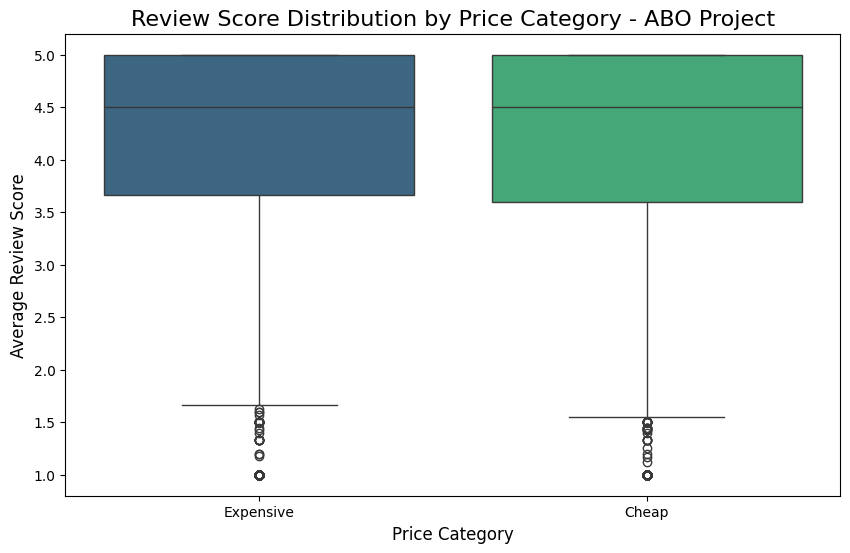

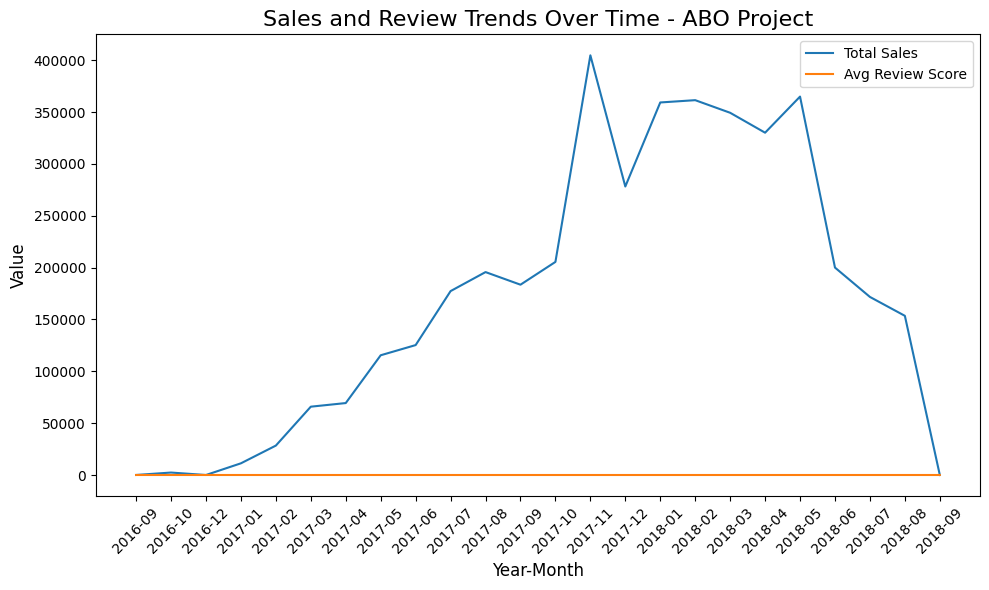

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


price_threshold = product_analysis['avg_price'].median()
product_analysis['price_category'] = product_analysis['avg_price'].apply(
    lambda x: 'Expensive' if x > price_threshold else 'Cheap'
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=product_analysis, x='price_category', y='avg_review_score', palette='viridis')
plt.title('Review Score Distribution by Price Category - ABO Project', fontsize=16)
plt.xlabel('Price Category', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(time_analysis['year_month'].astype(str), time_analysis['total_sales'], label='Total Sales')
plt.plot(time_analysis['year_month'].astype(str), time_analysis['avg_review_month'], label='Avg Review Score')
plt.title('Sales and Review Trends Over Time - ABO Project', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

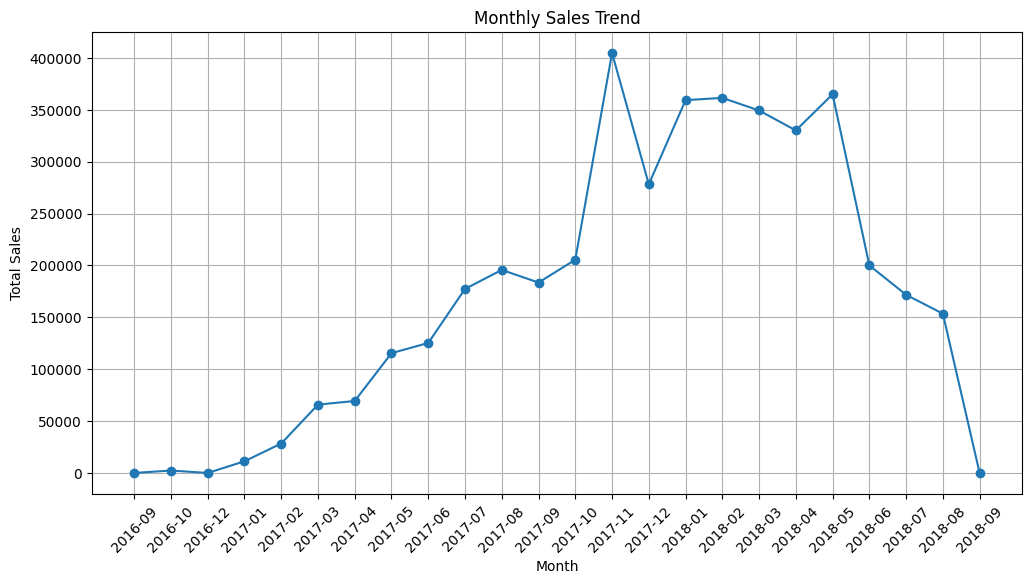

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(time_analysis['year_month'].astype(str), time_analysis['total_sales'], marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()


In [19]:
top_products = df.groupby('product_id').agg(
    total_sales=('order_id', 'count'),
    avg_price=('price', 'mean')
).sort_values(by='total_sales', ascending=False).head(10)

print(top_products)


                                  total_sales   avg_price
product_id                                               
aca2eb7d00ea1a7b8ebd4e68314663af          527   71.364137
99a4788cb24856965c36a24e339b6058          491   88.171609
422879e10f46682990de24d770e7f83d          487   54.895318
389d119b48cf3043d311335e499d9c6b          392   54.695383
368c6c730842d78016ad823897a372db          391   54.297954
53759a2ecddad2bb87a079a1f1519f73          375   54.653333
d1c427060a0f73f6b889a5c7c61f2ac4          343  137.651633
53b36df67ebb7c41585e8d54d6772e08          323  116.666935
154e7e31ebfa092203795c972e5804a6          293   22.515597
3dd2a17168ec895c781a9191c1e95ad7          274  149.936496


In [22]:
# طباعة الخلاصة
print("Summary of ABO Project:")
print(f"Average review score for Cheap products: {product_analysis[product_analysis['price_category'] == 'Cheap']['avg_review_score'].mean():.2f}")
print(f"Average review score for Expensive products: {product_analysis[product_analysis['price_category'] == 'Expensive']['avg_review_score'].mean():.2f}")
print("Recommendation: Focus on maintaining high review scores for cheap products to boost sales.")

Summary of ABO Project:
Average review score for Cheap products: 4.05
Average review score for Expensive products: 4.04
Recommendation: Focus on maintaining high review scores for cheap products to boost sales.


In [21]:
print(time_analysis.head())

  year_month  total_sales  avg_price_month  avg_review_month
0    2016-09           43        45.595920          2.034483
1    2016-10         2367       133.547135          3.689694
2    2016-12           10        10.900000          5.000000
3    2017-01        11275       124.736832          4.047765
4    2017-02        28369       126.720737          3.997963
